# Pattern Recognition 2 - Feature Space

**Objectives**

* Compute distances between objects in feature space
* Use PCA to perform reduce the dimensionality of the problem
* Implement face recognition using [Eigenfaces](http://en.wikipedia.org/wiki/Eigenface)

## Feature space distance

The `ocr_features.npy` file contains extracted features for each letter from the document used in the previous lab, and the `ocr_class.npy` file contains the character corresponding to these features.

The 18 features, extracted with the `regionprops` methods from `scikit-image` are, in order: 

> area, convex area, eccentricity, equivalent diameter, extent, filled area, intertia tensor eigenvalue 1, inertia tensor eigenvalue 2, major axis length, minor axis length, Hu moment 1, Hu moment 2, Hu moment 3, Hu moment 4, Hu moment 5, Hu moment 6, perimeter, solidity

* Create a method which computes the Euclidian distance, in feature space, between two objects.
* Check if the "nearest" object is of the same class.
* What can you do to improve this "distance-based" classification? 

In [3]:
import numpy as np

ocr_features = np.load('C:/Users/regna/Documents/ULB/MA2/Q2/INFO_H501/INFO_H501/docs/LABS/ocr_features.npy')
ocr_class = np.load('C:/Users/regna/Documents/ULB/MA2/Q2/INFO_H501/INFO_H501/docs/LABS/ocr_class.npy')

print(ocr_features.shape)
print(np.unique(ocr_class))

(2392, 18)
['0' '1' '4' '5' 'A' 'B' 'C' 'D' 'F' 'G' 'I' 'L' 'M' 'N' 'O' 'R' 'S' 'T'
 'W' 'a' 'b' 'c' 'd' 'e' 'f' 'g' 'h' 'i' 'k' 'l' 'm' 'n' 'o' 'p' 'q' 'r'
 's' 't' 'u' 'v' 'w' 'x' 'y' 'z']


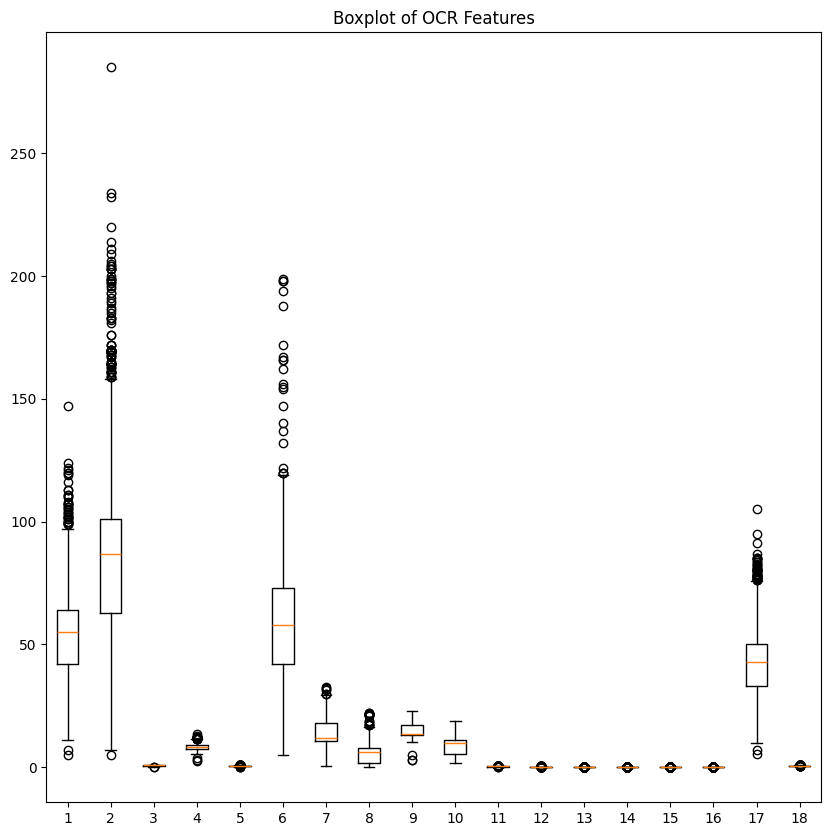

In [5]:
from matplotlib import pyplot as plt
%matplotlib inline
plt.figure(figsize=(10, 10))
plt.boxplot(ocr_features)
plt.title('Boxplot of OCR Features')
plt.show()

Normalization has to be perfomed to avoid imbalance in distance feature space

In [8]:
ocr_features_norm = (ocr_features - np.mean(ocr_features, axis=0)) / np.std(ocr_features, axis=0)

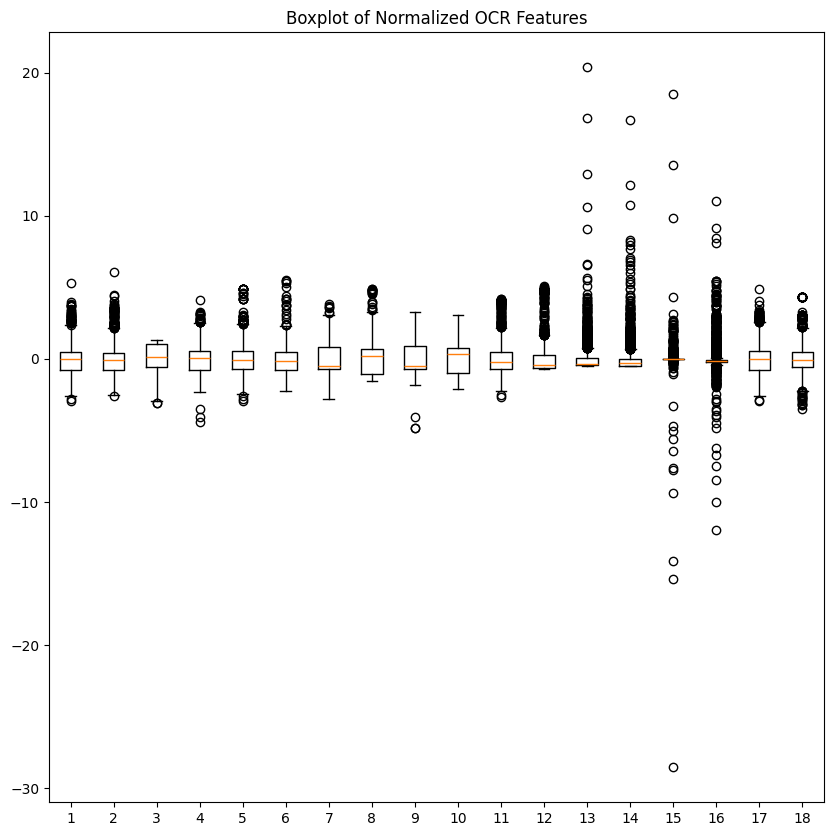

In [9]:
plt.figure(figsize=(10, 10))
plt.boxplot(ocr_features_norm)
plt.title('Boxplot of Normalized OCR Features')
plt.show()

In [12]:
def euclidian_distance(x1,x2):
    return(np.sqrt((x1-x2)**2).sum())
best_matches = []
for i in range(ocr_features_norm.shape[0]):
    best_match = -1
    best_d = 100000
    for j in range(ocr_features_norm.shape[0]):
        if (i==j): continue
        d = euclidian_distance(ocr_features_norm[i], ocr_features_norm[j])
        if (d<best_d):
            best_match = j
            best_d = d
    best_matches.append((i, ocr_class[i], best_match, ocr_class[best_match], best_d))


In [13]:

best_matches = np.array(best_matches)
print(best_matches[:10])

accuracy = (best_matches[:,1] == best_matches[:,3]).sum()/best_matches.shape[0]
print(accuracy)

[['0' 'i' '1377' 'i' '0.0']
 ['1' 'u' '1108' 'n' '0.7624373107586003']
 ['2' 'i' '568' 'i' '0.6017242454942465']
 ['3' 'a' '80' 'a' '0.7522598172895985']
 ['4' 'e' '1889' 'e' '1.0135592134001756']
 ['5' 'm' '2266' 'm' '1.7308931758958386']
 ['6' 't' '1599' 't' '0.0']
 ['7' 'o' '2143' 'o' '0.6558660645834649']
 ['8' 'w' '1221' 'w' '1.1195116414612525']
 ['9' 's' '1306' 's' '1.055524409574442']]
0.9540133779264214


Check des erreurs : 

In [16]:
for match in best_matches :
        if match[1] != match[3]: 
            print(match)

['1' 'u' '1108' 'n' '2.063227142611445']
['24' 'h' '415' 'w' '10.27817056844962']
['25' 'l' '2150' '1' '3.45527213095124']
['49' 'a' '1141' 'e' '5.1659797152888425']
['59' 'L' '2311' 'T' '29.01427064238585']
['66' 'e' '1020' 'c' '4.8346702208203345']
['68' 'l' '1352' '1' '2.669556431713747']
['69' 'e' '2009' 'c' '3.59145367020313']
['70' 'y' '2040' 'f' '24.230984232468373']
['75' 'u' '1516' 'n' '2.769051349737218']
['77' 't' '639' 'i' '2.7660902511476677']
['80' 'a' '2044' 'e' '3.3990858317355728']
['81' 'a' '1749' 's' '4.217414633292545']
['107' 'W' '831' 'R' '47.97097493304646']
['122' 'b' '738' 'd' '14.590617605280904']
['126' 'd' '1961' 'b' '3.4311410232401114']
['140' 'u' '707' 'n' '3.8761755009853274']
['142' 'b' '774' 'd' '3.9545853935880113']
['148' 'u' '1759' 'n' '2.924100305861619']
['168' 'v' '333' 'a' '5.121150171610813']
['171' 'b' '1018' 'd' '2.5104256133816385']
['176' '1' '1197' 'l' '4.646175709461522']
['177' 'n' '344' 'u' '2.886464144509813']
['217' 'r' '1266' 'i' '8.

"u" and "n" are often confuse, because a lot of features are rotation invariants 

## Eigenfaces

The `faces.npy` file contains a 3D matrix containing 2963 images, each with 170x200 pixels, encoded in 8-bit grayscale.

In [18]:
from matplotlib import pyplot as plt
%matplotlib notebook

faces = np.load("C:/Users/regna/Documents/ULB/MA2/Q2/INFO_H501/INFO_H501/docs/LABS/faces.npy")
print(faces.shape, faces.dtype, faces.min(), faces.max())

(2963, 200, 170) uint8 0 255


C:\Users\regna\AppData\Local\Temp\ipykernel_23340\1799160394.py:4: UserWarning: Reading `.npy` or `.npz` file required additional header parsing as it was created on Python 2. Save the file again to speed up loading and avoid this warning.
  faces = np.load("C:/Users/regna/Documents/ULB/MA2/Q2/INFO_H501/INFO_H501/docs/LABS/faces.npy")


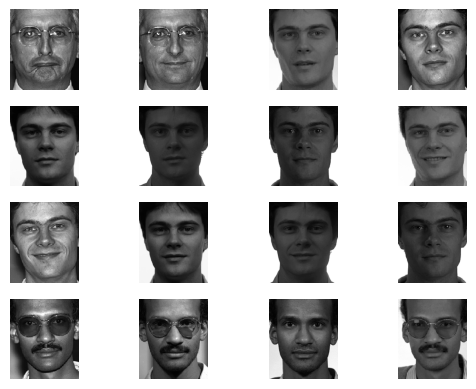

In [20]:
# Show some faces:
%matplotlib inline
plt.figure()
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(faces[i], cmap=plt.cm.gray)
    plt.axis('off')
plt.show()

### Direct approach

1. Write a program that subsample the images (e.g. by 5), converts 2D images into lines, and collect all these lines into one single matrix **T**.
1. Zero-center **T** by removing the "mean image" ($T_i \leftarrow T_i - T_{mean}$)
1. Compute the variance/covariance matrix of **T**:
$$ \mathbf{S} = \mathbf{T^TT}$$
1. Compute the eigenvalues $\lambda_i$ and eigenvectors $\mathbf{v}_i$ of **S**
$$\mathbf{Sv}_i = \mathbf{T^T}\mathbf{Tv}_i = \lambda_i \mathbf{v}_i$$
1. The eigenvectors have the same size as the images, and are often referred to as "eigenfaces". Display some of them.

In [14]:
# Example of eigen value extraction
import numpy as np
from numpy import linalg as LA

w,v = LA.eig(np.diag((1, 2, 3)))
print(w,v)

[1. 2. 3.] [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


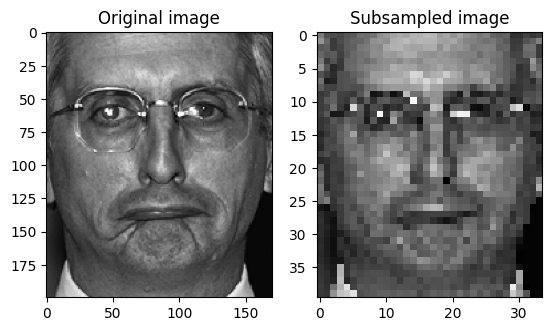

In [30]:
# Example of subsampling
im = faces[0]
plt.figure()
plt.subplot(1,2,1)
plt.imshow(im, cmap=plt.cm.gray)
plt.title("Original image")
plt.subplot(1,2,2)
plt.imshow(im[::5,::5], cmap=plt.cm.gray)
plt.title("Subsampled image")
plt.show()

(1360,)
(2963, 1360)
(1360, 1360)


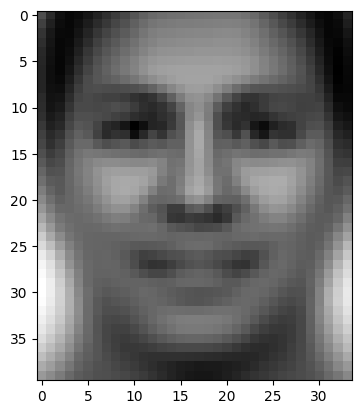

In [ ]:
T = np.array([face[::5,::5].flatten() for face in faces ])
im_mean = T.mean(axis=0)
print(im_mean.shape)
T = T - im_mean
print(T.shape)

#moyenne de tout les visages 

plt.figure()
plt.imshow(im_mean.reshape((200//5,170//5)), cmap=plt.cm.gray)
plt.show()


In [39]:
S = np.dot(T.T,T)
print(S.shape)
w, v = LA.eig(S) #w : eigenvalues , v: eigenvectors
print(w.shape,v.shape)

(1360, 1360)
(1360,) (1360, 1360)


In [48]:
order = w.argsort()[::-1]
w = w[order]
v = v[:,order]


In [70]:
explained_variance = w/w.sum()

for i in range(len(explained_variance)):
    if explained_variance[:i].sum()>0.9:
        print(i,explained_variance[:i].sum())
        break
for i in range(len(explained_variance)):
    if explained_variance[:i].sum()>0.95:
        print(i,explained_variance[:i].sum())
        break

109 0.9004433563654015
248 0.9502026266840315


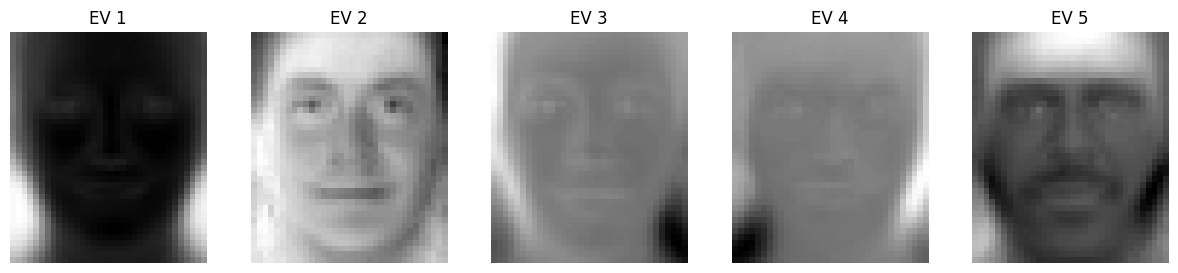

In [49]:
plt.figure(figsize=(15,3))

for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(v[:, i].reshape((40,34)), cmap='gray')
    plt.axis('off')
    plt.title(f'EV {i+1}')

plt.show()

### Compression

1. Reconstruct images using only the first N eigenfaces (e.g. N=100).
2. Compare (visually) reconstructed images with original images

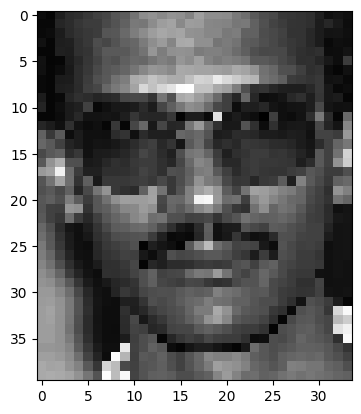

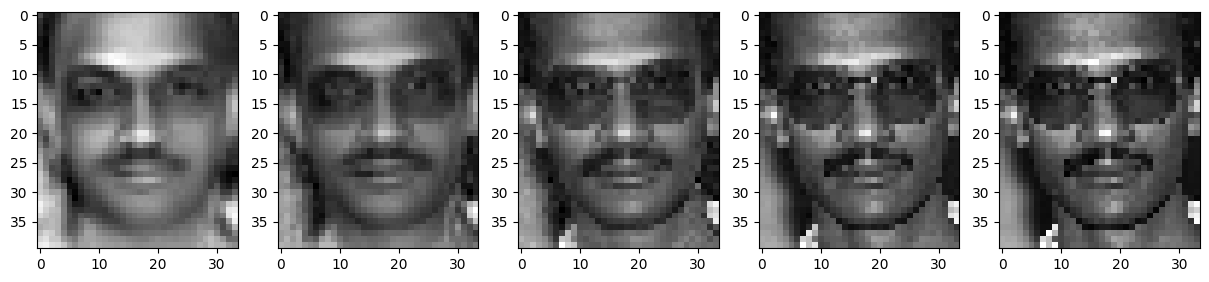

In [69]:
#projection d'un visage dans l'espace des eigenfaces
def encode(im,n):
    return np.dot(im,v)[:n]


#reconstruction (im = coef1xeigenface1 + coef2xeigenface2 +...)
def decode(encoded,n):
        return np.dot(encoded, (v.T)[:n])

face = T[12]
N = 50


plt.figure()
plt.imshow((face+im_mean).reshape((40,34)), cmap = plt.cm.gray)
plt.figure(figsize=(15,10))

for i in range(5):
    plt.subplot(1,5,i+1)
    N = N+i*100
    encoded = encode(face,N)
    decoded = decode(encoded,N)
    plt.imshow((decoded+im_mean).reshape((40,34)), cmap = plt.cm.gray)
plt.show()




On peut voir qu'on utilise principalement les premiers vecteur propres pour reconstruire l'image

### Face recognition

1. Using the simplified vector space (e.g. 100 first eigenfaces), compute the euclidian distance between one face and the others.
2. For a subset of the image of the database, find the 4 closest matches.

In [71]:
N=250
T_weights = np.array([encode(face,N) for face in T])
print(T_weights.shape)


(2963, 250)


0.0


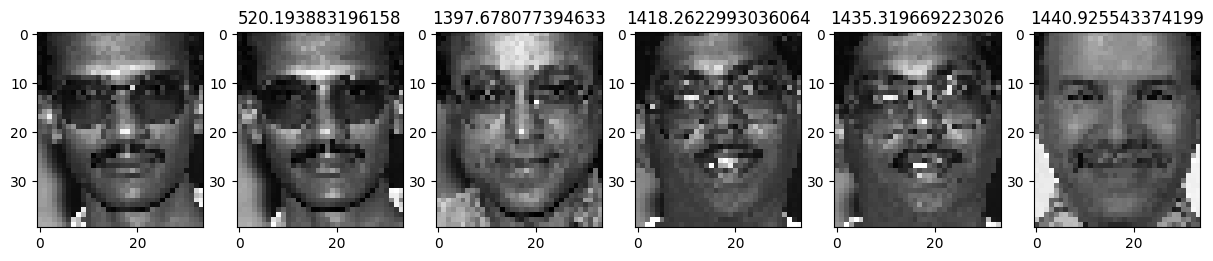

In [81]:
face_id = 12
distances = np.sqrt(((T_weights-T_weights[face_id])**2).sum(axis=1))
print(distances[face_id])
distances[face_id] = distances.max()
best_matches = np.argsort(distances)

plt.figure(figsize=(15,5))
plt.subplot(1,6,1)
plt.imshow((im_mean+T[face_id]).reshape((40,34)), cmap=plt.cm.gray)
for i in range(5):
    plt.subplot(1,6,i+2)
    plt.imshow((im_mean+T[best_matches[i]]).reshape((40,34)), cmap= plt.cm.gray)
    plt.title(distances[best_matches[i]])
plt.show()


### Indirect approach

Instead of using the eigenvalues/eigenvectors of $\mathbf{S} = \mathbf{T^TT}$, compute the the eigenvalues/eigenvectors of $\mathbf{Q} = \mathbf{TT^T}$.

Let $\mathbf{u_i}$ be the eigenvectors of $\mathbf{Q}$. We have:
$$\mathbf{TT^T}\mathbf{u}_i = \lambda_i \mathbf{u}_i$$

By multiplying to the left with $\mathbf{T^T}$, we have:
$$\mathbf{T^T}\mathbf{TT^T}\mathbf{u}_i = \lambda_i\mathbf{T^T}\mathbf{u}_i$$
$$\mathbf{S}\mathbf{T^T}\mathbf{u}_i = \lambda_i\mathbf{T^T}\mathbf{u}_i$$

Which means that if $\mathbf{u}_i$ is eigenvector of $\mathbf{Q}$, then $\mathbf{T^T}\mathbf{u}_i$ is eigenvector of $\mathbf{S}$.

The indirect approach thus becomes:
1. Compute the eigenvectors $\mathbf{u}_i$ of $\mathbf{Q} = \mathbf{TT^T}$.
1. Compute the eigenfaces with $\mathbf{v}_i = \mathbf{T^T}\mathbf{u}_i$ 
1. Reconstruct the images using only the first N eigenfaces (e.g. N=100)
1. Compare (visually) reconstructed images with original images
1. Use the indirect approach with more resolution (without subsampling the images)

Use this new feature space to perform the same face recognition method.

In [83]:
T = np.array([face[::5,::5].flatten() for face in faces])
h, w = faces[0][::5,::5].shape
print(h,w)
im_mean = T.mean(axis=0)
T = T - im_mean



40 34


In [84]:
Q = np.dot(T,T.T)
eigvals, eigvectors = np.linalg.eigh(Q)


In [86]:
# Sort by decreasing eigenvalue
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvectors = eigvectors[:, idx]

In [87]:
#eigenfaces
v = np.dot(T.T, eigvectors)
v = v / np.linalg.norm(v, axis=0, keepdims=True)

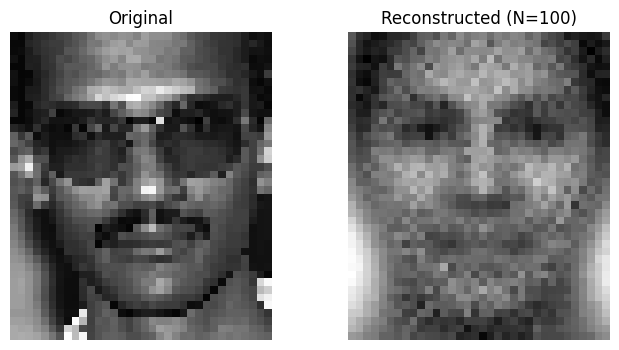

In [89]:
# Reconstruction using the first N eigenfaces
N = 100
V = v[:, :N]

face = T[12]

encoded = np.dot(face,V)
decoded = np.dot(encoded ,V.T)

original = face + im_mean
reconstructed = decoded + im_mean

# Display
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(original.reshape((h,w)), cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(reconstructed.reshape((h,w)), cmap='gray')
plt.title(f"Reconstructed (N={N})")
plt.axis('off')

plt.show()